# LOSO Cross-Validation with SMOTE

Identical protocol to `loso_evaluation.ipynb` but SMOTE is applied inside each training fold to address the 75/25 class imbalance.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

PALETTE = {
    "PD":      "#E24B4A",
    "Healthy": "#378ADD",
    "SVM":     "#7F77DD",
    "HGB":     "#1D9E75",
    "LR":      "#BA7517",
    "RF":      "#B07FC8",
    "All":     "#D4537E",
    "JS":      "#639922",
}

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

## Load Data
see `loso_evaluation.ipynb`

In [12]:
train_a = pd.read_csv('../data/train_a.csv')
test_a  = pd.read_csv('../data/test_a.csv')
train_b = pd.read_csv('../data/train_b.csv')
test_b  = pd.read_csv('../data/test_b.csv')

full_a = pd.concat([train_a, test_a], ignore_index=True)
full_b = pd.concat([train_b, test_b], ignore_index=True)

feature_cols = [c for c in full_a.columns if c not in ('name', 'status')]
JITTER_SHIMMER = [
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA',
]

for df in [full_a, full_b]:
    df['subject'] = df['name'].str.rsplit('_', n=1).str[0]

print(f'Dataset A: {len(full_a)} recordings, {full_a["subject"].nunique()} subjects')
print(f'Dataset B: {len(full_b)} recordings, {full_b["subject"].nunique()} subjects')
print(f'Status distribution A: {full_a["status"].value_counts().sort_index().to_dict()}  (0=Healthy, 1=PD)')

# SMOTE safety check: needs >= k_neighbors+1 minority samples in every training fold.
# With k=5 (default), need >= 6 healthy recordings per training fold.
healthy_a = (full_a['status'] == 0).sum()
print(f'\nSMOTE safety check (Dataset A): {healthy_a} healthy recordings total.')
print(f'Worst-case inner train fold (5-fold of ~31 subjects): '
      f'~{int(healthy_a * 0.8 * 0.8)} healthy samples — well above k=5 threshold.')

Dataset A: 195 recordings, 32 subjects
Dataset B: 187 recordings, 32 subjects
Status distribution A: {0.0: 48, 1.0: 147}  (0=Healthy, 1=PD)

SMOTE safety check (Dataset A): 48 healthy recordings total.
Worst-case inner train fold (5-fold of ~31 subjects): ~30 healthy samples — well above k=5 threshold.


## LogTransformer
see `loso_evaluation.ipynb`

In [13]:
SKEWED_FEATURES = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)',
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'PPE', 'spread1', 'D2',
]


class LogTransformer(BaseEstimator, TransformerMixin):
    """Log-transform skewed features; fit on training fold only."""

    def __init__(self, skewed_cols, all_cols):
        self.skewed_cols = skewed_cols
        self.all_cols    = all_cols

    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols)
        self.mins_    = {c: df[c].min()             for c in self.skewed_cols}
        self.use_log_ = {c: bool((df[c] > 0).all()) for c in self.skewed_cols}
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols).copy()
        for c in self.skewed_cols:
            if self.use_log_[c]:
                df[c] = np.log(df[c])
            else:
                df[c] = np.log1p(df[c] - self.mins_[c])
        return df.values

## LOSO Evaluation Function
see `loso_evaluation.ipynb`

In [14]:
def loso_evaluate(pipe, param_grid, X, y, groups,
                  inner_k=5, scoring='balanced_accuracy'):
    logo = LeaveOneGroupOut()
    ba_scores, f1_scores = [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        g_tr       = groups[train_idx]

        n_inner  = min(inner_k, len(np.unique(g_tr)))
        inner_cv = GroupKFold(n_splits=n_inner)

        gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                          scoring=scoring, n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr, groups=g_tr)

        y_pred = gs.predict(X_te)
        ba_scores.append(balanced_accuracy_score(y_te, y_pred))
        f1_scores.append(f1_score(y_te, y_pred, average='macro', zero_division=0))

    return np.array(ba_scores), np.array(f1_scores)

## Model Pipelines and Hyperparameter Grids

In [15]:
# SVM
def make_svm(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = ImbPipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),          # ← after scaler, no class_weight
        ('svm',    SVC(kernel='rbf', random_state=42)),
    ])
    grid = {
        'svm__C':     [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto'],
    }
    return pipe, grid


# Logistic Regression
def make_lr(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = ImbPipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('lr',     LogisticRegression(penalty='l1', solver='liblinear',
                                      random_state=42, max_iter=1000)),
    ])
    grid = {'lr__C': np.logspace(-3, 3, 10)}
    return pipe, grid


# HGB
def make_hgb():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('hgb',   HistGradientBoostingClassifier(
            random_state=42,
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        )),
    ])
    grid = {
        'hgb__learning_rate':    [0.03, 0.05, 0.08, 0.1],
        'hgb__max_iter':         [100, 200, 300],
        'hgb__max_leaf_nodes':   [5, 10, 15, 20, 31],
        'hgb__l2_regularization':[0.0, 0.01, 0.1, 1.0],
        'hgb__min_samples_leaf': [5, 10, 20],
    }
    return pipe, grid


# Random Forest
def make_rf(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = ImbPipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('rf',     RandomForestClassifier(random_state=42)),
    ])
    grid = {
        'rf__n_estimators':     [100, 200],
        'rf__max_depth':        [None, 10, 20],
        'rf__min_samples_leaf': [1, 5],
    }
    return pipe, grid


print('Grid sizes (combos × 5 inner folds × 32 outer folds):')
for name, g in [('SVM', {'C':[0.1,1,10,100],'gamma':['scale','auto']}),
                ('LR',  {'C': list(np.logspace(-3,3,10))}),
                ('HGB', {'lr':[0.03,0.05,0.08,0.1],'iter':[100,200,300],
                         'leaf':[5,10,15,20,31],'l2':[0.0,0.01,0.1,1.0],'ms':[5,10,20]}),
                ('RF',  {'n':[100,200],'d':[None,10,20],'ms':[1,5]})]:
    n = 1
    for v in g.values(): n *= len(v)
    print(f'  {name}: {n} combos × 5 × 32 = {n*5*32} total fits')

Grid sizes (combos × 5 inner folds × 32 outer folds):
  SVM: 8 combos × 5 × 32 = 1280 total fits
  LR: 10 combos × 5 × 32 = 1600 total fits
  HGB: 720 combos × 5 × 32 = 115200 total fits
  RF: 12 combos × 5 × 32 = 1920 total fits


## LOSO Run

In [16]:
import time

OUT_CSV = 'outputs/loso_smote_results.csv'

if os.path.exists(OUT_CSV):
    print(f'Found {OUT_CSV} — loading existing results. Delete file to re-run.')
    df_loso = pd.read_csv(OUT_CSV)
    display(df_loso)
else:
    datasets     = {'A': full_a, 'B': full_b}
    feat_configs = {'All features': feature_cols, 'Jitter+Shimmer': JITTER_SHIMMER}
    loso_rows = []
    t0 = time.time()

    for ds_key, df_full in datasets.items():
        y      = df_full['status'].values.astype(int)
        groups = df_full['subject'].values

        for feat_label, fc in feat_configs.items():
            X = df_full[fc].values

            for model_label, make_fn in [
                ('SVM', lambda: make_svm(fc)),
                ('LR',  lambda: make_lr(fc)),
                ('RF',  lambda: make_rf(fc)),
                ('HGB', lambda: make_hgb()),
            ]:
                print(f'[{model_label}] Dataset {ds_key} | {feat_label} ...', flush=True)
                t1 = time.time()
                pipe, grid = make_fn()
                ba, f1 = loso_evaluate(pipe, grid, X, y, groups)
                elapsed = time.time() - t1
                print(f'  → BA = {ba.mean():.3f} ± {ba.std():.3f}  '
                      f'F1 = {f1.mean():.3f} ± {f1.std():.3f}  [{elapsed/60:.1f} min]')
                loso_rows.append({
                    'Model':    model_label,
                    'Dataset':  ds_key,
                    'Features': feat_label,
                    'BA_mean':  round(ba.mean(), 3),
                    'BA_std':   round(ba.std(),  3),
                    'F1_mean':  round(f1.mean(), 3),
                    'F1_std':   round(f1.std(),  3),
                    'n_folds':  len(ba),
                })

    df_loso = pd.DataFrame(loso_rows)
    df_loso.to_csv(OUT_CSV, index=False)
    print(f'\nTotal runtime: {(time.time()-t0)/60:.1f} min')
    print(f'Saved: {OUT_CSV}')
    display(df_loso)

Found outputs/loso_smote_results.csv — loading existing results. Delete file to re-run.


,Model,Dataset,Features,BA_mean,BA_std,F1_mean,F1_std,n_folds
0,SVM,A,All features,0.714,0.369,0.596,0.387,32
1,LR,A,All features,0.690,0.358,0.575,0.376,32
2,RF,A,All features,0.745,0.368,0.655,0.393,32
3,HGB,A,All features,0.740,0.373,0.653,0.393,32
4,SVM,A,Jitter+Shimmer,0.619,0.418,0.565,0.426,32
5,LR,A,Jitter+Shimmer,0.656,0.392,0.604,0.410,32
6,RF,A,Jitter+Shimmer,0.684,0.345,0.593,0.376,32
7,HGB,A,Jitter+Shimmer,0.685,0.297,0.573,0.342,32
8,SVM,B,All features,0.674,0.390,0.577,0.400,32
9,LR,B,All features,0.710,0.357,0.599,0.378,32


## Results Table

In [17]:
df_loso = pd.read_csv('outputs/loso_smote_results.csv')

df_loso['BA'] = df_loso.apply(lambda r: f"{r.BA_mean:.3f} \u00b1 {r.BA_std:.3f}", axis=1)
df_loso['F1'] = df_loso.apply(lambda r: f"{r.F1_mean:.3f} \u00b1 {r.F1_std:.3f}", axis=1)

pivot = df_loso.pivot_table(
    index=['Model', 'Dataset'],
    columns='Features',
    values=['BA', 'F1'],
    aggfunc='first'
)
display(pivot)

BA                            F1               
Features        All features Jitter+Shimmer   All features Jitter+Shimmer
Model Dataset                                                            
HGB   A        0.740 ± 0.373  0.685 ± 0.297  0.653 ± 0.393  0.573 ± 0.342
      B        0.725 ± 0.370  0.659 ± 0.355  0.616 ± 0.388  0.582 ± 0.383
LR    A        0.690 ± 0.358  0.656 ± 0.392  0.575 ± 0.376  0.604 ± 0.410
      B        0.710 ± 0.357  0.642 ± 0.397  0.599 ± 0.378  0.581 ± 0.412
RF    A        0.745 ± 0.368  0.684 ± 0.345  0.655 ± 0.393  0.593 ± 0.376
      B        0.709 ± 0.382  0.654 ± 0.360  0.623 ± 0.402  0.563 ± 0.380
SVM   A        0.714 ± 0.369  0.619 ± 0.418  0.596 ± 0.387  0.565 ± 0.426
      B        0.674 ± 0.390  0.621 ± 0.417  0.577 ± 0.400  0.550 ± 0.421

## Visualisation

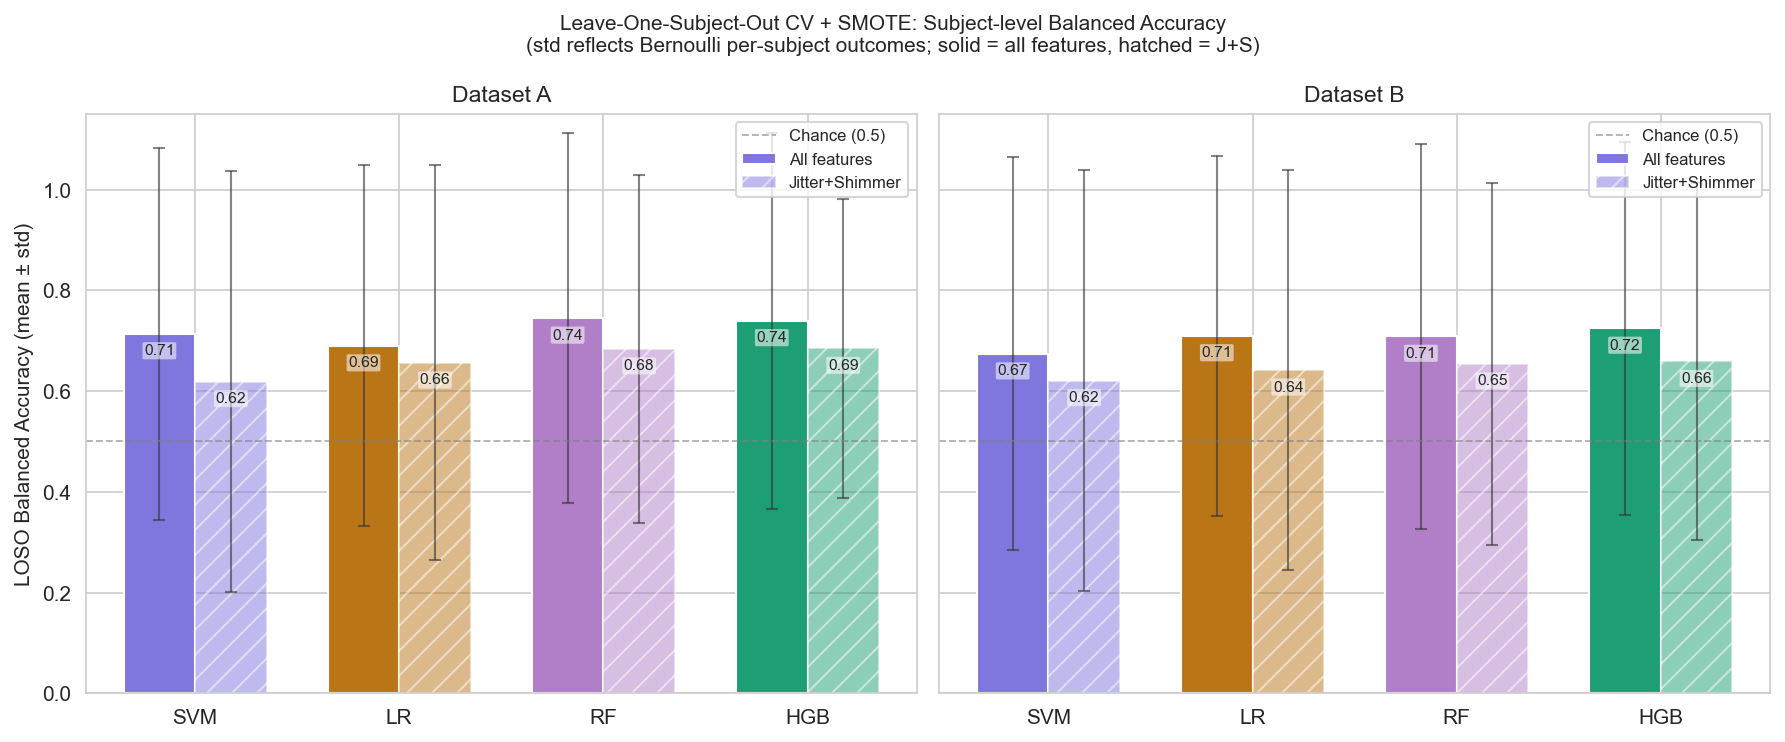

Saved: outputs/loso_smote_results.png


In [18]:
df_loso = pd.read_csv('outputs/loso_smote_results.csv')

model_order = ['SVM', 'LR', 'RF', 'HGB']
feat_order  = ['All features', 'Jitter+Shimmer']
feat_alpha  = {'All features': 1.0, 'Jitter+Shimmer': 0.5}
feat_hatch  = {'All features': '',  'Jitter+Shimmer': '//'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
x     = np.arange(len(model_order))
width = 0.35

for ax, ds_key in zip(axes, ['A', 'B']):
    df_ds = df_loso[df_loso['Dataset'] == ds_key]

    for i, feat in enumerate(feat_order):
        df_f   = df_ds[df_ds['Features'] == feat].set_index('Model')
        means  = [df_f.loc[m, 'BA_mean'] if m in df_f.index else 0 for m in model_order]
        stds   = [df_f.loc[m, 'BA_std']  if m in df_f.index else 0 for m in model_order]
        colors = [PALETTE[m] for m in model_order]
        offset = (i - 0.5) * width

        bars = ax.bar(x + offset, means, width,
                      yerr=stds, capsize=3,
                      error_kw=dict(elinewidth=1.0, ecolor='#333333', alpha=0.6),
                      color=colors, alpha=feat_alpha[feat],
                      hatch=feat_hatch[feat], edgecolor='white', label=feat)
        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() - 0.02,
                        f'{mean:.2f}', ha='center', va='top', fontsize=7.5,
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.55, ec='none'))

    ax.axhline(0.5, color='grey', linestyle='--', lw=0.9, alpha=0.6, label='Chance (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Dataset {ds_key}', fontsize=11)
    ax.set_ylabel('LOSO Balanced Accuracy (mean \u00b1 std)' if ds_key == 'A' else '')
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'Leave-One-Subject-Out CV + SMOTE: Subject-level Balanced Accuracy\n'
    '(std reflects Bernoulli per-subject outcomes; solid = all features, hatched = J+S)',
    fontsize=10
)
plt.tight_layout()
plt.savefig('outputs/loso_smote_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/loso_smote_results.png')

## Comparison: Baseline vs SMOTE

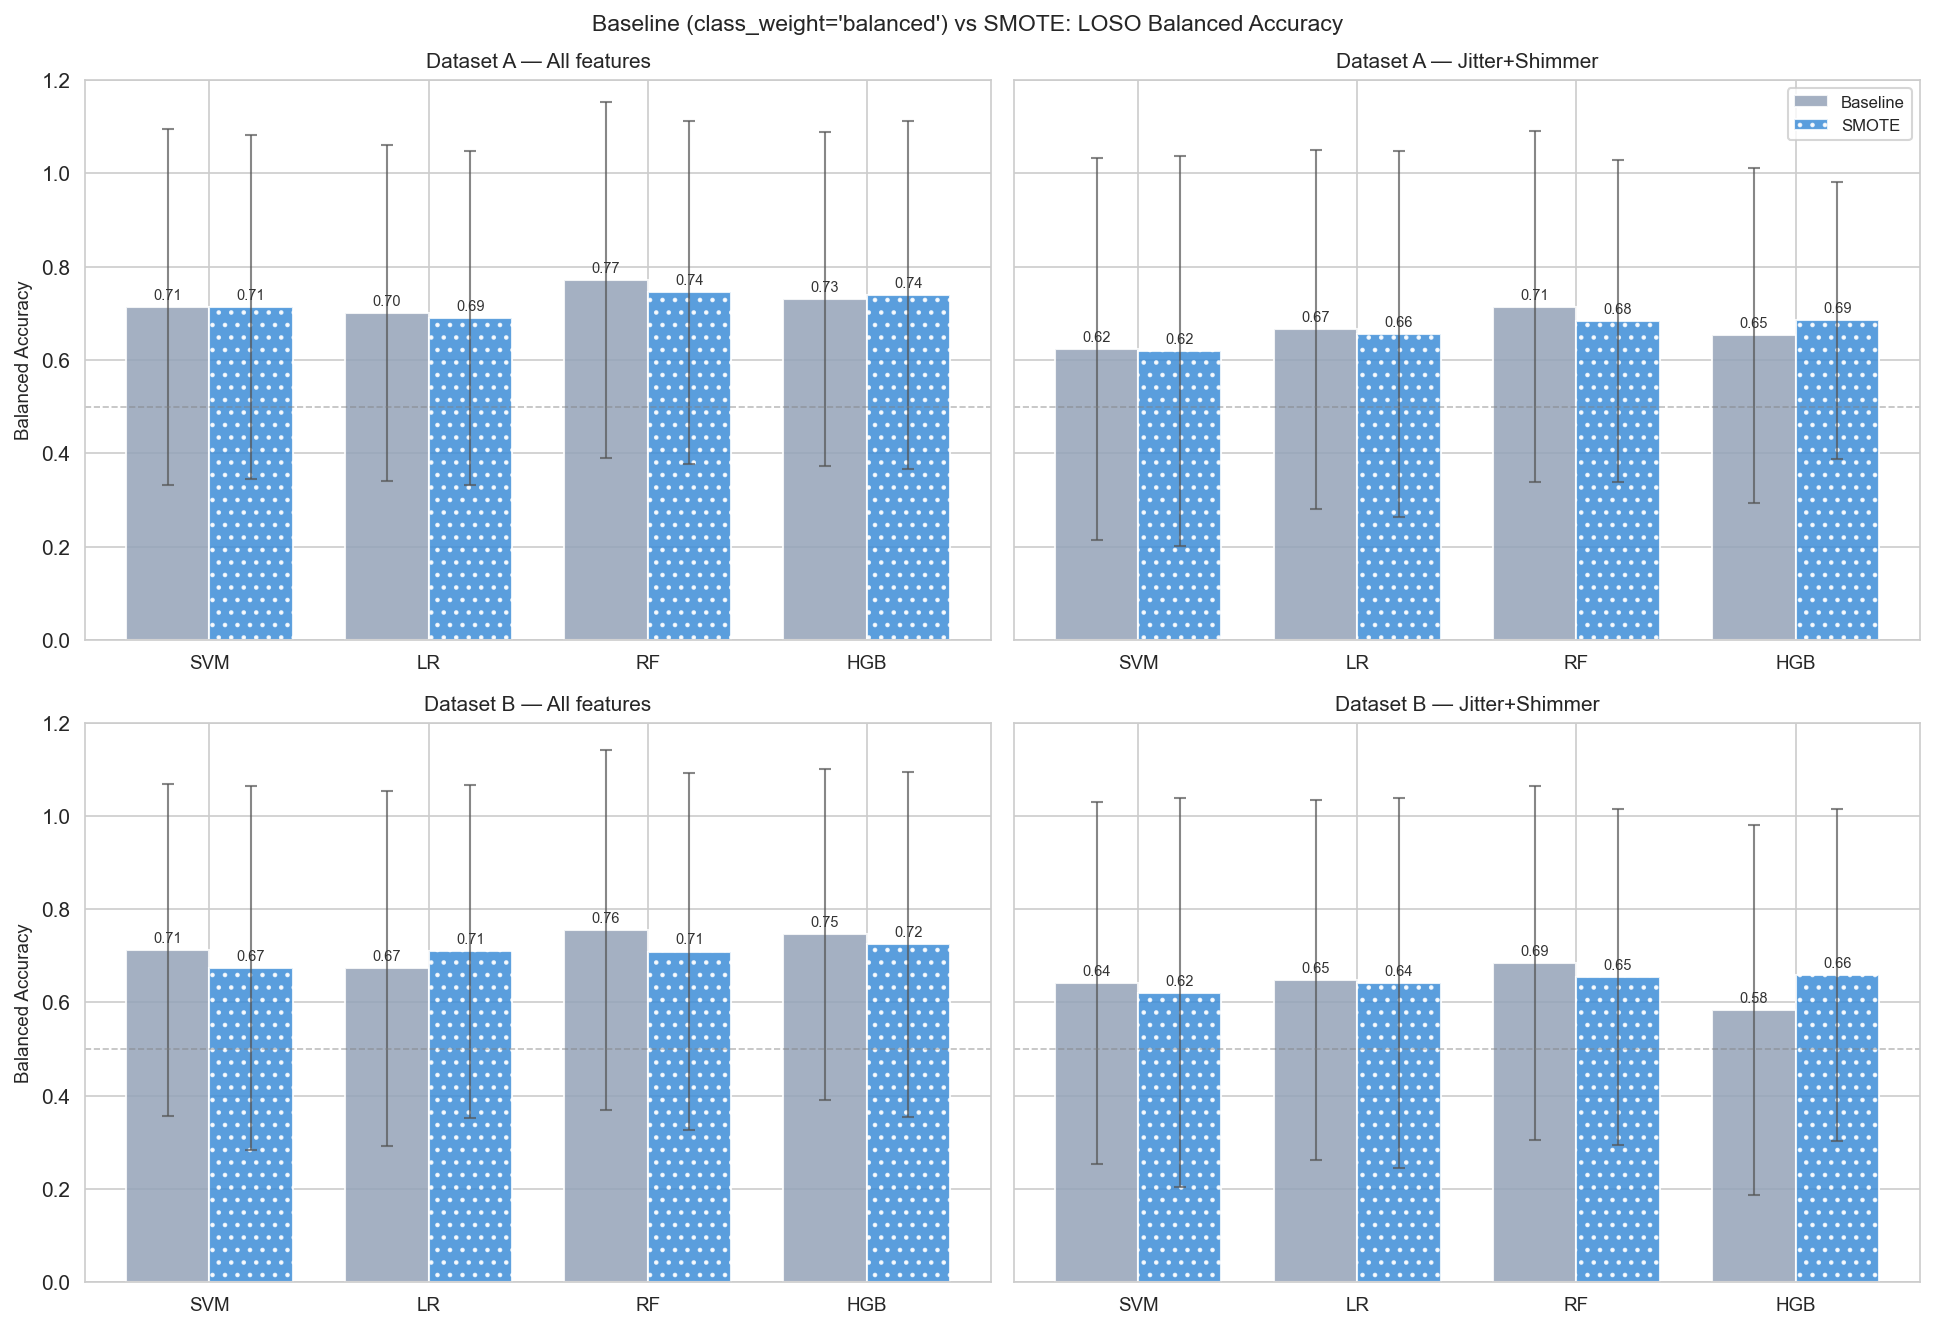

Saved: outputs/loso_comparison_smote_vs_baseline.png

BA delta (SMOTE minus Baseline):


Condition                     Baseline  SMOTE  Delta
Model Dataset Features                              
HGB   B       Jitter+Shimmer     0.584  0.659  0.075
LR    B       All features       0.673  0.710  0.037
HGB   A       Jitter+Shimmer     0.653  0.685  0.032
              All features       0.730  0.740  0.010
SVM   A       All features       0.714  0.714  0.000
              Jitter+Shimmer     0.624  0.619 -0.005
LR    B       Jitter+Shimmer     0.648  0.642 -0.006
      A       All features       0.700  0.690 -0.010
              Jitter+Shimmer     0.666  0.656 -0.010
SVM   B       Jitter+Shimmer     0.641  0.621 -0.020
HGB   B       All features       0.746  0.725 -0.021
RF    A       All features       0.771  0.745 -0.026
              Jitter+Shimmer     0.714  0.684 -0.030
      B       Jitter+Shimmer     0.685  0.654 -0.031
SVM   B       All features       0.712  0.674 -0.038
RF    B       All features       0.755  0.709 -0.046

In [19]:
baseline_csv = 'outputs/loso_results.csv'
smote_csv    = 'outputs/loso_smote_results.csv'

if not (os.path.exists(baseline_csv) and os.path.exists(smote_csv)):
    print('One or both result files are missing. Run loso_evaluation.ipynb first.')
else:
    df_base  = pd.read_csv(baseline_csv)
    # loso_results.csv has an Outliers column ('With'/'Without'); compare against
    # the full-dataset baseline to match the SMOTE setup (all 32 subjects).
    if 'Outliers' in df_base.columns:
        df_base = df_base[df_base['Outliers'] == 'With']
    df_base  = df_base.assign(Condition='Baseline')
    df_smote = pd.read_csv(smote_csv).assign(Condition='SMOTE')
    df_cmp   = pd.concat([df_base, df_smote], ignore_index=True)

    model_order = ['SVM', 'LR', 'RF', 'HGB']
    cond_order  = ['Baseline', 'SMOTE']
    cond_color  = {'Baseline': '#94a3b8', 'SMOTE': "#3d8dd7"}
    cond_hatch  = {'Baseline': '',         'SMOTE': '..'}

    n_ds   = 2
    n_feat = 2
    fig, axes = plt.subplots(n_ds, n_feat, figsize=(13, 9), sharey=True)
    x     = np.arange(len(model_order))
    width = 0.38

    for row, ds_key in enumerate(['A', 'B']):
        for col, feat_label in enumerate(['All features', 'Jitter+Shimmer']):
            ax = axes[row][col]
            df_sub = df_cmp[(df_cmp['Dataset'] == ds_key) &
                            (df_cmp['Features'] == feat_label)]

            for i, cond in enumerate(cond_order):
                df_c   = df_sub[df_sub['Condition'] == cond].set_index('Model')
                means  = [df_c.loc[m, 'BA_mean'] if m in df_c.index else 0 for m in model_order]
                stds   = [df_c.loc[m, 'BA_std']  if m in df_c.index else 0 for m in model_order]
                offset = (i - 0.5) * width

                bars = ax.bar(x + offset, means, width,
                              yerr=stds, capsize=3,
                              error_kw=dict(elinewidth=1.0, ecolor='#555', alpha=0.7),
                              color=cond_color[cond],
                              hatch=cond_hatch[cond],
                              edgecolor='white', label=cond, alpha=0.85)
                for bar, mean in zip(bars, means):
                    if mean > 0:
                        ax.text(bar.get_x() + bar.get_width() / 2,
                                bar.get_height() + 0.01,
                                f'{mean:.2f}', ha='center', va='bottom',
                                fontsize=7, color='#333')

            ax.axhline(0.5, color='grey', linestyle='--', lw=0.8, alpha=0.5)
            ax.set_xticks(x)
            ax.set_xticklabels(model_order, fontsize=9)
            ax.set_ylim(0, 1.2)
            ax.set_title(f'Dataset {ds_key} — {feat_label}', fontsize=10)
            if col == 0:
                ax.set_ylabel('Balanced Accuracy', fontsize=9)
            if row == 0 and col == 1:
                ax.legend(fontsize=8)

    fig.suptitle(
        'Baseline (class_weight=\'balanced\') vs SMOTE: LOSO Balanced Accuracy',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig('outputs/loso_comparison_smote_vs_baseline.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/loso_comparison_smote_vs_baseline.png')

    # Delta table
    df_delta = (df_cmp.pivot_table(index=['Model','Dataset','Features'],
                                    columns='Condition', values='BA_mean')
                       .assign(Delta=lambda d: d['SMOTE'] - d['Baseline'])
                       .sort_values('Delta', ascending=False))
    print('\nBA delta (SMOTE minus Baseline):')
    display(df_delta.round(3))